# PTB-XL ECG Dataset Analysis — Baseline Pipeline
## CS437/CS5317/EE414/EE513 — Deep Learning, Spring 2026
### Hassan Iftikhar (27100204) | Saim Bilal (27100208)

This notebook implements the **complete Baseline pipeline** for the project:
**Morphologically Grounded ECG Arrhythmia Classification using 1D-ResNet + Grad-CAM**

Sections covered end-to-end:
1. Data loading & metadata parsing
2. Multi-lead signal preprocessing (Butterworth + Z-score)
3. Dataset splits & class-imbalance handling
4. Exploratory visualisation with P/QRS/T annotations
5. 1D-ResNet architecture definition
6. Training loop with AdamW + ReduceLROnPlateau + BCEWithLogitsLoss
7. **Model saving / checkpoint management**
8. Test-set evaluation (Macro-AUC + per-class AUC + MAS)
9. Grad-CAM heatmap visualisation against morphological mask

## 1. Dataset Overview
- **Name:** PTB-XL
- **Size:** 21,799 recordings from 18,869 patients
- **Length:** 10 seconds per recording at 500 Hz → 5000 samples/lead
- **Leads used (Baseline):** I (idx 0), II (idx 1), V1 (idx 6)
- **Classes (Diagnostic Superclass):**

| Class | Description | # Records |
|-------|-------------|-----------|
| NORM  | Normal ECG | 9514 |
| MI    | Myocardial Infarction | 5469 |
| STTC  | ST/T Change | 5235 |
| CD    | Conduction Disturbance | 4898 |
| HYP   | Hypertrophy | 2649 |

## 2. Libraries & Dependencies
- `wfdb` : loading ECG waveform files (.hea/.dat)
- `pandas / numpy` : data manipulation
- `matplotlib` : visualisation
- `scipy.signal` : Butterworth bandpass filter (`filtfilt`)
- `neurokit2` : P/QRS/T boundary extraction (MAS ground truth)
- `torch / torch.nn` : 1D-ResNet model, training, Grad-CAM
- `sklearn.metrics` : `roc_auc_score` for Macro-AUC
- `ast` : parse SCP code dictionaries from CSV

In [ ]:
pip install wfdb neurokit2

In [53]:
# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import wfdb
import neurokit2 as nk
import ast
import os
import time
import copy
import warnings
from collections import Counter
from pathlib import Path

warnings.filterwarnings('ignore')

# Signal processing
from scipy.signal import butter, filtfilt
from scipy import signal as sp_signal

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Metrics
from sklearn.metrics import roc_auc_score

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
print(f"NumPy    : {np.__version__}")
print("All imports OK ✓")

PyTorch  : 2.10.0+cu128
Device   : cuda
NumPy    : 2.0.2
All imports OK ✓


## 3. Global Constants & Configuration

All pipeline-wide constants are defined here **once** so every subsequent cell
can reference them without ambiguity.

In [54]:
# === PATH CONFIGURATION ===
# DATA_PATH = "/mnt/d/lums_nerd_stuff/jnr_spring/CS437/project/baseline_deliverable/ptb-xl/"
DATA_PATH = "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/"
CHECKPOINT_DIR = "/kaggle/working/checkpoint"
# CHECKPOINT_DIR.mkdirs(parents=True, exist_ok=True)
# CHECKPOINT_DIR = "/mnt/d/lums_nerd_stuff/jnr_spring/CS437/project/baseline_deliverable/checkpoints/"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# === SIGNAL PARAMETERS ===
FS = 500 # Hz
SIGNAL_LEN = 5000 # samples (10 s x 500 Hz)

# === LEAD CONFIGURATION ===
LEAD_INDICES = [0, 1, 6] # Lead I, Lead II, V1
LEAD_NAMES = ['I', 'II', 'V1']
N_LEADS = len(LEAD_INDICES) # 3

# === FILTER PARAMETERS ===
BUTTER_LOWCUT = 0.5 # Hz
BUTTER_HIGHCUT = 40.0 # Hz
BUTTER_ORDER = 3

# === LABEL CONFIGURATION ===
SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
N_CLASSES = len(SUPERCLASSES)

# === TRAINING CONFIGURATION ===
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS = 70 # increase for full training run
PATIENCE_LR = 5 # ReduceLROnPlateau patience
FACTOR_LR = 0.1

# Verify data paths
assert os.path.exists(DATA_PATH + "ptbxl_database.csv"),  "ptbxl_database.csv not found"
assert os.path.exists(DATA_PATH + "scp_statements.csv"),  "scp_statements.csv not found"
assert os.path.exists(DATA_PATH + "records500/"),          "records500/ directory not found"

print("Data path verified ✓")
print(f"Checkpoint dir : {CHECKPOINT_DIR}")
print(f"Device : {DEVICE}")
print(f"Leads : {LEAD_NAMES} -> tensor shape (3 x {SIGNAL_LEN})")

Data path verified ✓
Checkpoint dir : /kaggle/working/checkpoint
Device : cuda
Leads : ['I', 'II', 'V1'] -> tensor shape (3 x 5000)


## 4. Loading PTB-XL Metadata & Labels

We load `ptbxl_database.csv`, filter to records with at least one diagnostic
superclass label via `scp_statements.csv`, and binarise the multi-label targets
into a 5-column vector `[NORM, MI, STTC, CD, HYP]`.

In [55]:
# === Load raw metadata ===
df = pd.read_csv(DATA_PATH + "ptbxl_database.csv", index_col="ecg_id")

scp_df = pd.read_csv(DATA_PATH + "scp_statements.csv", index_col=0)
scp_df = scp_df[scp_df.diagnostic == 1]   # keep only diagnostic codes

print(f"Total records  : {len(df):,}")
print(f"Total patients : {df['patient_id'].nunique():,}")
df.head(3)

Total records  : 21,837
Total patients : 18,885


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr


In [56]:
# === Parse SCP codes & extract superclass labels ===
df['scp_codes'] = df['scp_codes'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

def get_superclass(scp_codes):
    """Return list of diagnostic superclasses present in this record."""
    superclasses = []
    for code, likelihood in scp_codes.items():
        if code in scp_df.index:
            sc = scp_df.loc[code, 'diagnostic_class']
            if pd.notna(sc) and likelihood > 0:
                superclasses.append(sc)
    return list(set(superclasses))

df['superclass'] = df['scp_codes'].apply(get_superclass)

# Keep only records with ≥1 valid superclass
df_filtered = df[df['superclass'].map(len) > 0].copy()

# Build binary multi-label matrix  shape: (N, 5)
for cls in SUPERCLASSES:
    df_filtered[cls] = df_filtered['superclass'].apply(lambda x: int(cls in x))

print(f"Records with valid superclass labels : {len(df_filtered):,}")
print(f"Label matrix columns added           : {SUPERCLASSES}")
df_filtered[SUPERCLASSES].head(10)

Records with valid superclass labels : 21,417
Label matrix columns added           : ['NORM', 'MI', 'STTC', 'CD', 'HYP']


,NORM,MI,STTC,CD,HYP
ecg_id,,,,,
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0
5,1,0,0,0,0
6,1,0,0,0,0
7,1,0,0,0,0
8,0,1,0,0,0
9,1,0,0,0,0


## 5. Class Distribution

Class Distribution:
--------------------------------
  NORM  :  9,528  (44.5%)
  MI    :  5,486  (25.6%)
  STTC  :  5,123  (23.9%)
  CD    :  4,907  (22.9%)
  HYP   :  2,655  (12.4%)


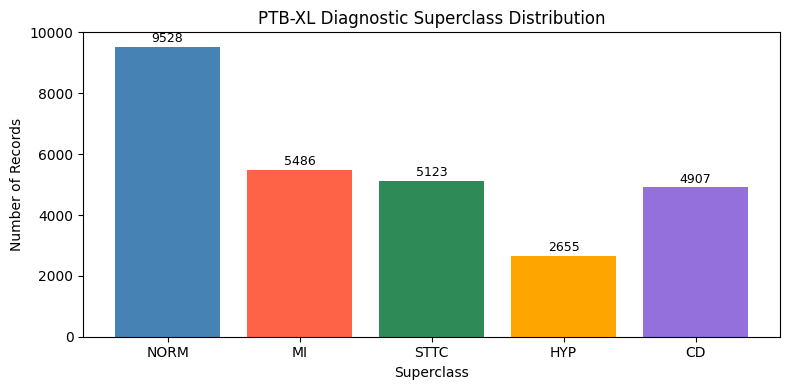

In [57]:
# === Flatten and count ===
all_labels   = [lbl for sub in df_filtered['superclass'] for lbl in sub]
label_counts = Counter(all_labels)

print("Class Distribution:")
print("-" * 32)
for lbl, cnt in sorted(label_counts.items(), key=lambda x: -x[1]):
    pct = cnt / len(df_filtered) * 100
    print(f"  {lbl:<6}: {cnt:>6,}  ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'mediumpurple']
bars   = ax.bar(label_counts.keys(), label_counts.values(), color=colors)
for bar, (lbl, cnt) in zip(bars, label_counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(cnt), ha='center', va='bottom', fontsize=9)
ax.set_title("PTB-XL Diagnostic Superclass Distribution")
ax.set_xlabel("Superclass")
ax.set_ylabel("Number of Records")
plt.tight_layout()
plt.show()

## 6. Dataset Split — Inter-Patient Protocol

| Folds | Set | Purpose |
|-------|-----|---------|
| 1–8 | Training | Model optimisation |
| 9 | Validation | Learning-rate scheduling, early stopping |
| 10 | Test | **Held-out** final evaluation only |

All recordings from a single patient reside in exactly one fold, preventing
any patient-level data leakage.

In [ ]:
# === Split by strat_fold ===
train_df = df_filtered[df_filtered['strat_fold'] <= 8].copy()
val_df = df_filtered[df_filtered['strat_fold'] == 9].copy()
test_df = df_filtered[df_filtered['strat_fold'] == 10].copy()

print(f"Training set : {len(train_df):>6,} records  (folds 1–8)")
print(f"Validation set : {len(val_df):>6,} records  (fold 9)")
print(f"Test set : {len(test_df):>6,} records  (fold 10)")

# Confirm zero patient overlap
train_pids = set(train_df['patient_id'].unique())
test_pids  = set(test_df['patient_id'].unique())
overlap    = train_pids & test_pids
status     = "✓ No overlap" if len(overlap) == 0 else f"⚠ {len(overlap)} patients shared!"
print(f"\nPatient overlap (train/test) : {len(overlap)}  →  {status}")

Training set   : 17,100 records  (folds 1–8)
Validation set :  2,155 records  (fold 9)
Test set       :  2,162 records  (fold 10)

Patient overlap (train/test) : 0  →  ✓ No overlap


## 7. Signal Processing Pipeline

### Why Leads I, II, and V1?

| Lead | Plane | Key Clinical Information |
|------|-------|------------------------|
| **I** (idx 0) | Frontal | Lateral ST changes; left/right axis |
| **II** (idx 1) | Frontal | Best P-wave axis; inferior MI; RR rhythm |
| **V1** (idx 6) | Horizontal | RBBB/LBBB morphology; posterior MI; P mitrale |

### Butterworth Filter (0.5–40 Hz, 3rd order, zero-phase)

| Noise removed | Frequency | Clinical relevance |
|---------------|-----------|-------------------|
| Baseline wander | < 0.5 Hz | Respiratory artefact — distorts ST baseline |
| EMG / high-freq | > 40 Hz | Mimics fine QRS detail |

`filtfilt` (forward + backward pass) guarantees **zero phase distortion**,
preserving P/QRS/T timing — critical for the MAS ground-truth mask.

### Z-score normalisation (per lead)
$$x_{\text{norm}} = \frac{x - \mu}{\sigma + \epsilon}$$
Prevents leads with larger natural amplitude (V1 up to ±2 mV) from
dominating gradient signals in the ResNet.

In [59]:
def design_butterworth(lowcut=BUTTER_LOWCUT, highcut=BUTTER_HIGHCUT,
                       fs=FS, order=BUTTER_ORDER):
    """Return (b, a) coefficients for a zero-phase Butterworth bandpass."""
    nyq = 0.5 * fs # nyquist sampling frequency
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return b, a

BUTTERWORTH_B_COEFF, BUTTERWORTH_A_COEFF = design_butterworth()


def butterworth_filter(signal_1d, b=BUTTERWORTH_B_COEFF, a=BUTTERWORTH_A_COEFF):
    """Zero-phase Butterworth bandpass filter for a 1-D signal."""
    return filtfilt(b, a, signal_1d)


def zscore_normalize(signal_1d):
    """Per-lead Z-score: (x - mean) / (std + eps)."""
    return (signal_1d - signal_1d.mean()) / (signal_1d.std() + 1e-8)


# Multi-lead loader
def load_three_leads(row, data_path=DATA_PATH, lead_indices=LEAD_INDICES):
    """Load raw 3-lead tensor from a PTB-XL record row.

    Returns
    -------
    np.ndarray, shape (3, 5000), dtype float64
    """
    record = wfdb.rdrecord(data_path + row['filename_hr'])
    return record.p_signal[:, lead_indices].T   # (3, 5000)


def preprocess_record(row, data_path=DATA_PATH):
    """Full baseline preprocessing: load -> Butterworth -> Z-score.

    Returns
    -------
    np.ndarray, shape (3, 5000), dtype float32
    """
    raw = load_three_leads(row, data_path)        # (3, 5000)
    out = np.empty_like(raw, dtype=np.float32)
    for i in range(N_LEADS):
        out[i] = zscore_normalize(butterworth_filter(raw[i]))
    return out


def try_annotate_ecg(signal_1d, fs=FS):
    """Attempt NeuroKit2 ECG annotation; return (success, payload)."""
    try:
        cleaned = nk.ecg_clean(signal_1d, sampling_rate=fs)
        _, info = nk.ecg_peaks(cleaned, sampling_rate=fs)
        _, waves = nk.ecg_delineate(cleaned, info, sampling_rate=fs, method='peak')
        return True, {'cleaned': cleaned, 'peaks': info, 'waves': waves}
    except Exception:
        return False, {}


# Smoke test
sample_row = df_filtered.iloc[0]
prep_out = preprocess_record(sample_row)

print(f"Preprocessed shape : {prep_out.shape}  (expected 3 x {SIGNAL_LEN})")
for i, name in enumerate(LEAD_NAMES):
    print(f"  Lead {name:<3} - mean: {prep_out[i].mean():+.4f}  std: {prep_out[i].std():.4f}")

Preprocessed shape : (3, 5000)  (expected 3 x 5000)
  Lead I   - mean: -0.0000  std: 1.0000
  Lead II  - mean: +0.0000  std: 1.0000
  Lead V1  - mean: -0.0000  std: 1.0000


### Filter Frequency Response & Denoising Effect

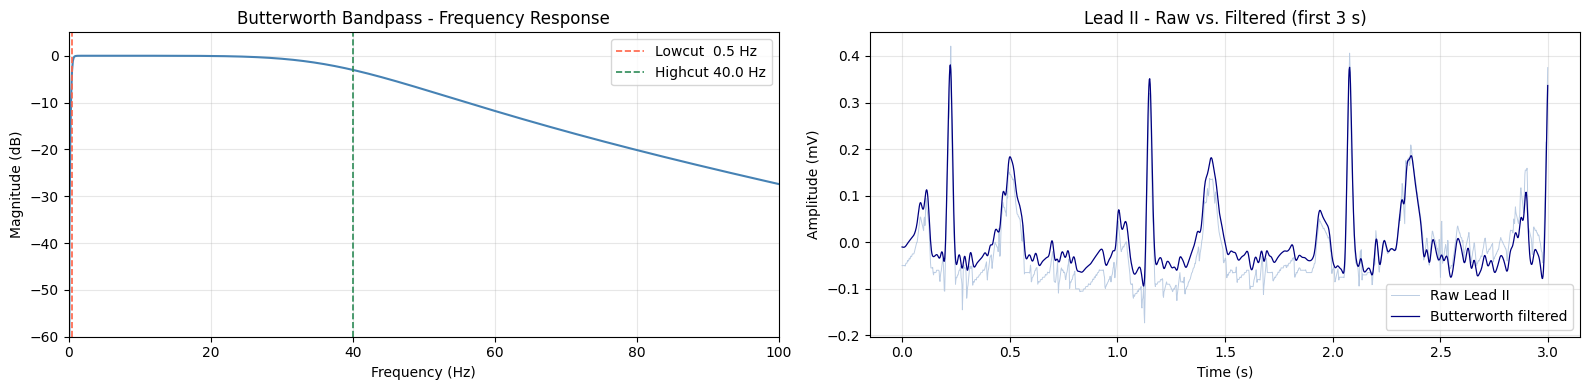

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left: Bode magnitude
w, h = sp_signal.freqz(BUTTERWORTH_B_COEFF, BUTTERWORTH_A_COEFF, worN=2048, fs=FS)
axes[0].plot(w, 20 * np.log10(np.abs(h) + 1e-12), color='steelblue', lw=1.5)
axes[0].axvline(BUTTER_LOWCUT,  color='tomato',   ls='--', lw=1.2, label=f'Lowcut  {BUTTER_LOWCUT} Hz')
axes[0].axvline(BUTTER_HIGHCUT, color='seagreen', ls='--', lw=1.2, label=f'Highcut {BUTTER_HIGHCUT} Hz')
axes[0].set(xlim=[0, 100], ylim=[-60, 5], xlabel='Frequency (Hz)', ylabel='Magnitude (dB)', title='Butterworth Bandpass - Frequency Response')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Right: Raw vs filtered (Lead II)
raw_l2 = load_three_leads(sample_row)[1]
flt_l2 = butterworth_filter(raw_l2)
time_vec = np.arange(SIGNAL_LEN) / FS

axes[1].plot(time_vec[:1500], raw_l2[:1500], color='lightsteelblue', lw=0.7, alpha=0.85, label='Raw Lead II')
axes[1].plot(time_vec[:1500], flt_l2[:1500], color='navy', lw=0.9, label='Butterworth filtered')
axes[1].set(xlabel='Time (s)', ylabel='Amplitude (mV)',
            title='Lead II - Raw vs. Filtered (first 3 s)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Sample ECG Visualisation

### 8.1 Single-Lead (Lead II) Overview — one sample per class

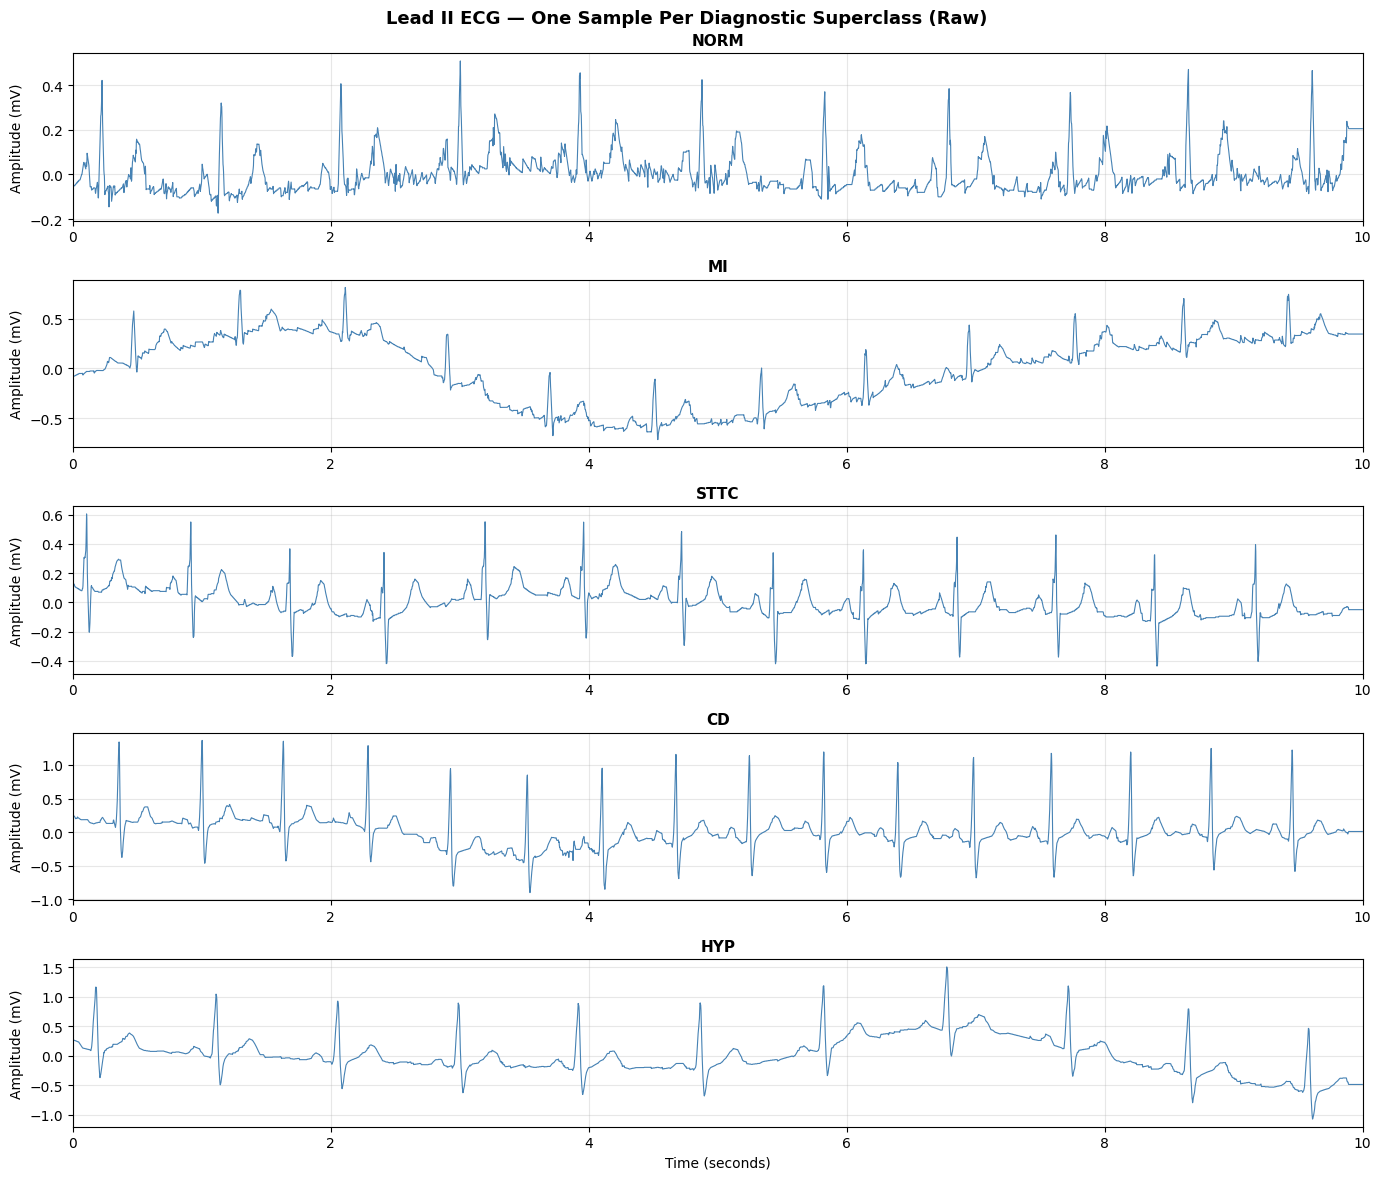

In [61]:
time_axis = np.arange(SIGNAL_LEN) / FS
fig, axes = plt.subplots(5, 1, figsize=(14, 12))

for i, cls in enumerate(SUPERCLASSES):
    row = df_filtered[df_filtered['superclass'].apply(lambda x: cls in x)].iloc[0]
    signal = load_three_leads(row)[1] # Lead II raw
    axes[i].plot(time_axis, signal, color='steelblue', linewidth=0.8)
    axes[i].set_title(cls, fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Amplitude (mV)")
    axes[i].set_xlim([0, 10])
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")
plt.suptitle("Lead II ECG — One Sample Per Diagnostic Superclass (Raw)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Multi-Lead Annotated Visualisation (Preprocessed)

Reading the three leads together:
- **P-wave in Lead II**: flat/absent → AF or junctional rhythm (→ CD)
- **ST elevation in II/V1**: ≥1 mm above J-point → STEMI (→ MI/STTC)
- **QRS width > 120 ms**: bundle branch block (→ CD); V1 morphology distinguishes RBBB from LBBB
- **T-wave inversion in V1**: normal; in II → ischaemia/strain (→ MI, STTC, HYP)

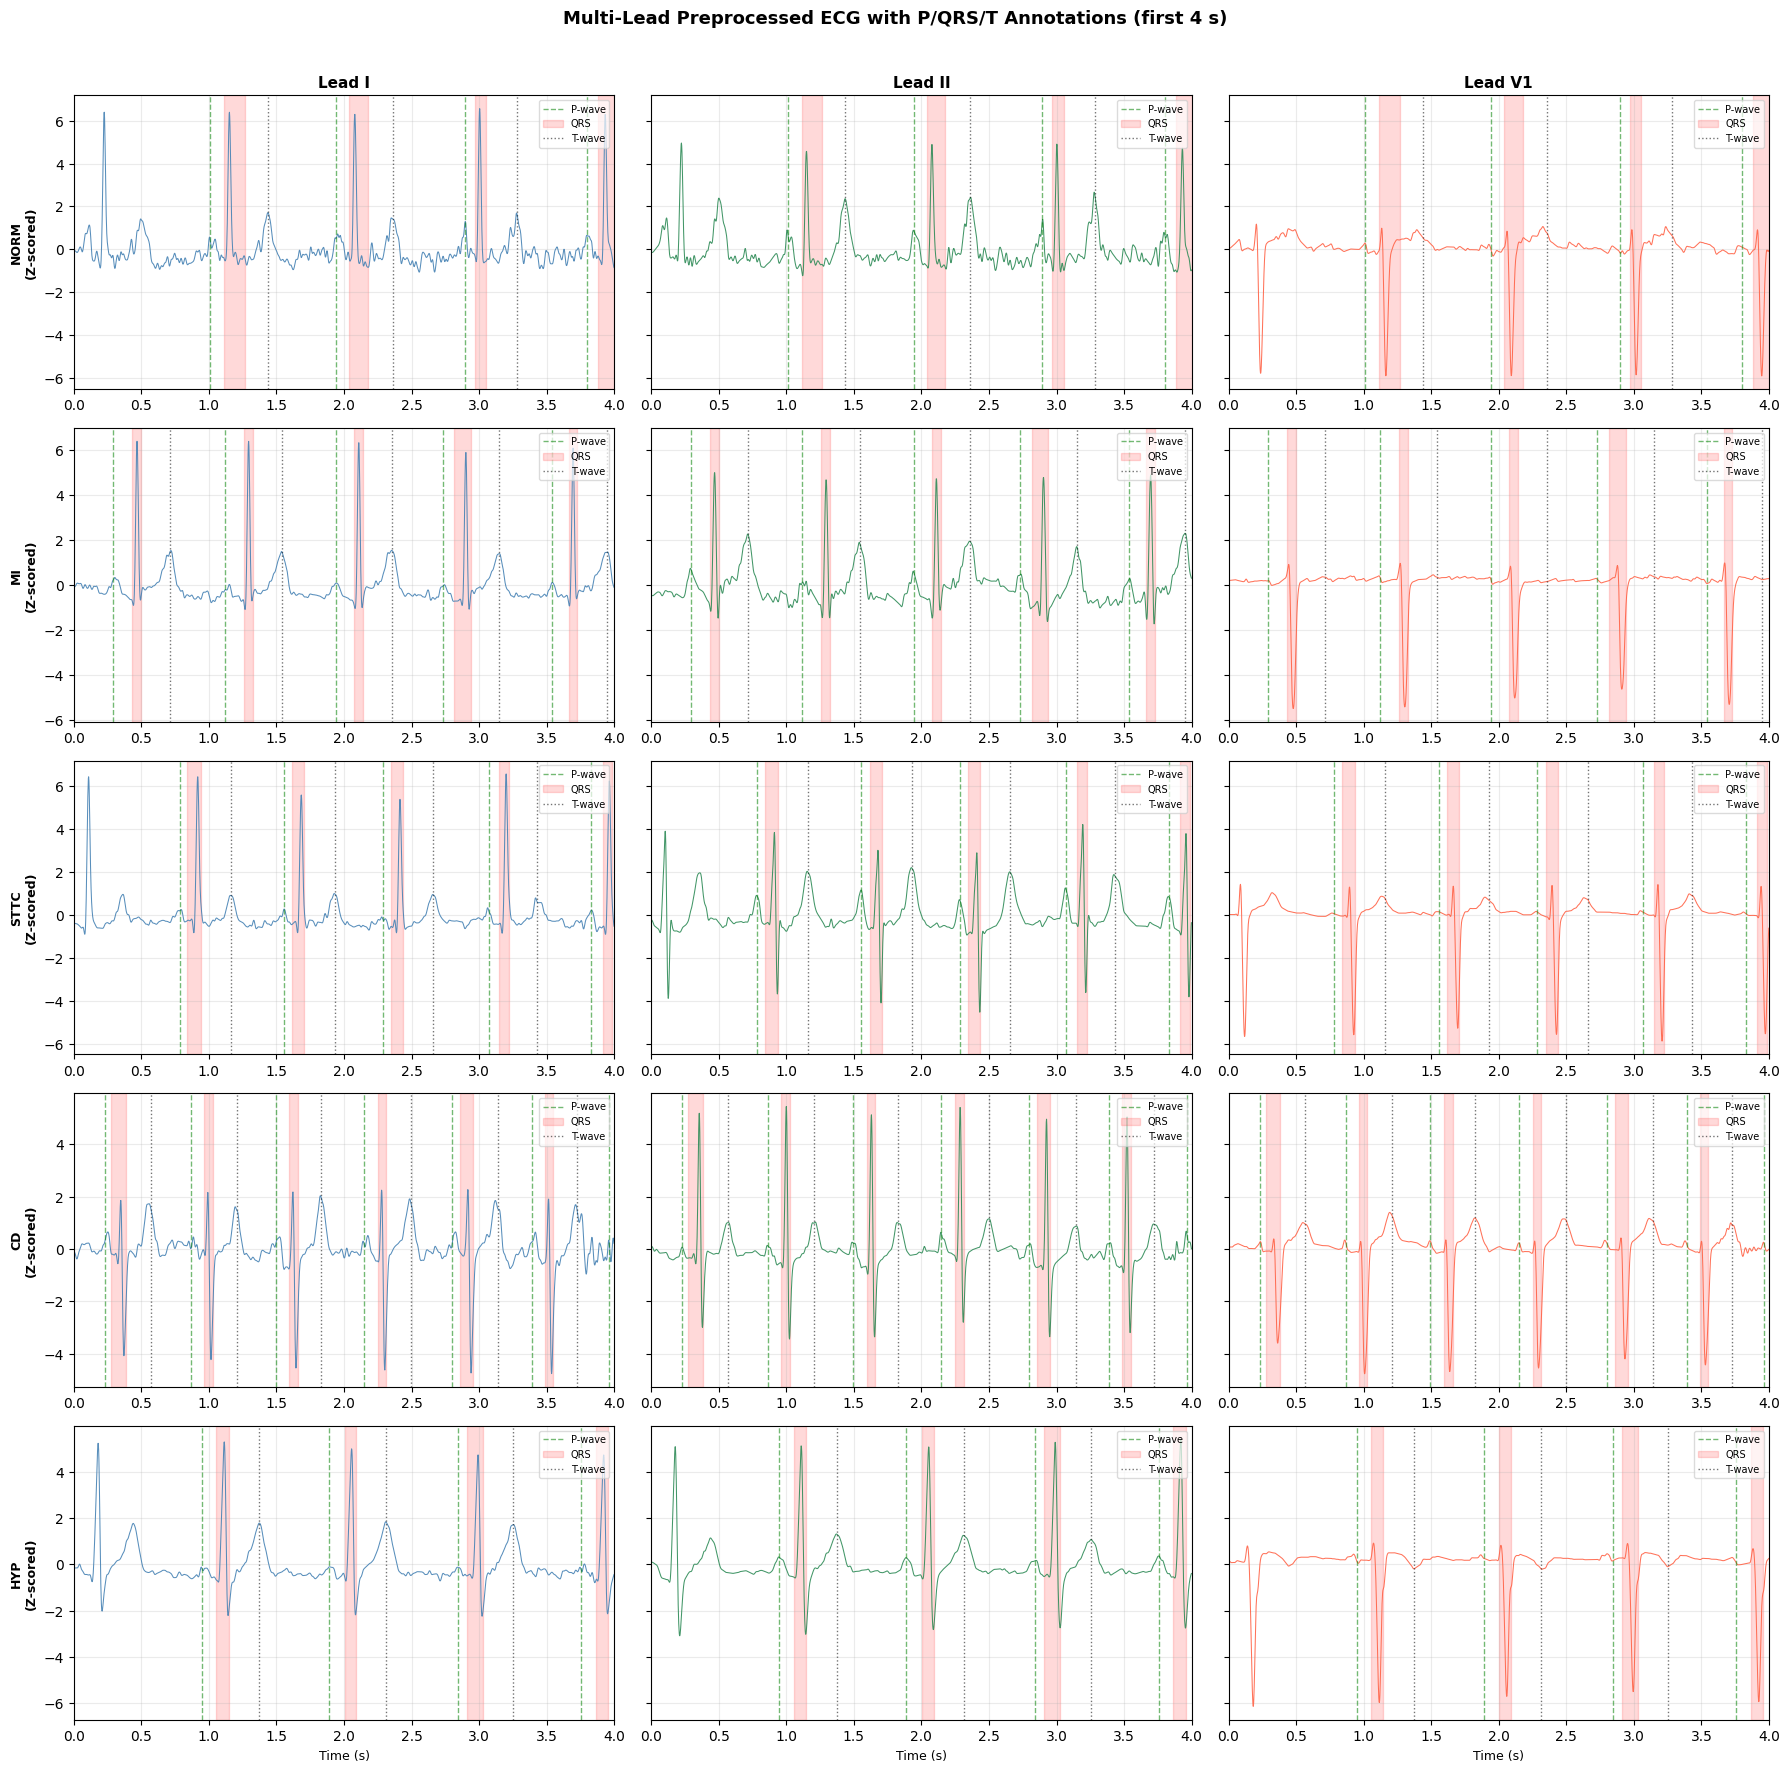

In [62]:
LEAD_COLORS = ['steelblue', 'seagreen', 'tomato']
PLOT_SECONDS = 4
plot_samples = PLOT_SECONDS * FS

fig, axes = plt.subplots(len(SUPERCLASSES), N_LEADS,
                          figsize=(18, 3.5 * len(SUPERCLASSES)), sharey='row')

for row_i, cls in enumerate(SUPERCLASSES):
    cls_row = df_filtered[df_filtered['superclass'].apply(lambda x: cls in x)].iloc[0]
    sig_3l  = preprocess_record(cls_row)   # (3, 5000)

    ann_ok, ann_data = try_annotate_ecg(sig_3l[1], fs=FS)
    wv = ann_data.get('waves', {})

    t = np.arange(plot_samples) / FS
    for col_j, (lead_sig, lname, color) in enumerate(zip(sig_3l, LEAD_NAMES, LEAD_COLORS)):
        ax = axes[row_i][col_j]
        ax.plot(t, lead_sig[:plot_samples], color=color, lw=0.75, alpha=0.9)

        # if col_j == 1 and ann_ok:
        if ann_ok:
            shown = {'P': False, 'QRS': False, 'T': False}
            for p in wv['ECG_P_Peaks']:
                if p is not None and not (isinstance(p, float) and np.isnan(p)) and p < plot_samples:
                    ax.axvline(p/FS, color='green', alpha=0.55, lw=1.0, ls='--',
                               label=('P-wave' if not shown['P'] else ''))
                    shown['P'] = True
            for q, s in zip(wv['ECG_Q_Peaks'], wv['ECG_S_Peaks']):
                if (q is not None and s is not None
                        and not (isinstance(q,float) and np.isnan(q))
                        and not (isinstance(s,float) and np.isnan(s)) and q < plot_samples):
                    ax.axvspan(q/FS, s/FS, color='red', alpha=0.15,
                               label=('QRS' if not shown['QRS'] else ''))
                    shown['QRS'] = True
            for tt in wv['ECG_T_Peaks']:
                if tt is not None and not (isinstance(tt,float) and np.isnan(tt)) and tt < plot_samples:
                    ax.axvline(tt/FS, color='black', alpha=0.55, lw=1.0, ls=':',
                               label=('T-wave' if not shown['T'] else ''))
                    shown['T'] = True
            ax.legend(loc='upper right', fontsize=7, framealpha=0.7)

        ax.set_xlim([0, PLOT_SECONDS])
        ax.grid(True, alpha=0.25)
        if row_i == 0:
            ax.set_title(f'Lead {lname}', fontsize=11, fontweight='bold')
        if col_j == 0:
            ax.set_ylabel(f'{cls}\n(Z-scored)', fontsize=9, fontweight='bold')
        if row_i == len(SUPERCLASSES) - 1:
            ax.set_xlabel('Time (s)', fontsize=9)

plt.suptitle('Multi-Lead Preprocessed ECG with P/QRS/T Annotations (first 4 s)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Morphological Mask & Medical Alignment Score

### What is the MAS?

$$MAS = \frac{\sum_t \text{GradCAM}(t) \cdot M(t)}{\sum_t \text{GradCAM}(t)}$$

| MAS | Interpretation |
|-----|---------------|
| ≈ 1.0 | Attention fully within P/QRS/T — clinically grounded |
| ≈ 0.4–0.6 | Random / weakly localised |
| < 0.3 | Attending to isoelectric baseline — clinically uninformative |

$M(t)$ is built by NeuroKit2 delineating every P-wave, QRS complex, and T-wave
boundary over the full 10-second strip.

In [65]:
def build_morphological_mask(signal_1d, fs=FS, signal_len=SIGNAL_LEN):
    """Binary P/QRS/T presence mask from NeuroKit2 delineation.

    Parameters
    ----------
    signal_1d : 1-D array, preprocessed Lead II signal (length signal_len)

    Returns
    -------
    np.ndarray bool, shape (signal_len,)

    Notes
    -----
    NeuroKit2 can emit None/NaN for some onsets, offsets, or peaks.
    The helper _idx() makes those values safe before indexing mask ranges.
    """
    mask = np.zeros(signal_len, dtype=bool)
    try:
        cleaned  = nk.ecg_clean(signal_1d, sampling_rate=fs)
        _, info  = nk.ecg_peaks(cleaned, sampling_rate=fs)
        _, waves = nk.ecg_delineate(cleaned, info, sampling_rate=fs, method='peak')

        # Safe cast to int index. Returns None for invalid values.
        def _idx(v):
            try:
                return None if (v is None or np.isnan(float(v))) else int(v)
            except (TypeError, ValueError):
                return None

        r_peaks = list(info.get('ECG_R_Peaks', []))
        n_beats = len(waves['ECG_P_Peaks'])

        # P-wave windows
        p_onsets  = waves.get('ECG_P_Onsets',  [None] * n_beats)
        p_offsets = waves.get('ECG_P_Offsets', [None] * n_beats)
        for p0, pp, p1 in zip(p_onsets, waves['ECG_P_Peaks'], p_offsets):
            pp_i = _idx(pp)
            i0 = _idx(p0) or (pp_i - 10 if pp_i is not None else None)
            i1 = _idx(p1) or (pp_i + 10 if pp_i is not None else None)
            if i0 is not None and i1 is not None:
                mask[max(0, i0):min(signal_len, i1 + 1)] = True

        # QRS windows
        r_ext = r_peaks + [None] * max(0, n_beats - len(r_peaks))
        for qp, sp, rp in zip(waves['ECG_Q_Peaks'], waves['ECG_S_Peaks'], r_ext):
            rp_i = _idx(rp)
            i0 = _idx(qp) or (rp_i - 8  if rp_i is not None else None)
            i1 = _idx(sp) or (rp_i + 8  if rp_i is not None else None)
            if i0 is not None and i1 is not None:
                mask[max(0, i0):min(signal_len, i1 + 1)] = True

        # T-wave windows
        t_onsets  = waves.get('ECG_T_Onsets',  [None] * n_beats)
        t_offsets = waves.get('ECG_T_Offsets', [None] * n_beats)
        for t0, tp, t1 in zip(t_onsets, waves['ECG_T_Peaks'], t_offsets):
            tp_i = _idx(tp)
            i0 = _idx(t0) or (tp_i - 20 if tp_i is not None else None)
            i1 = _idx(t1) or (tp_i + 20 if tp_i is not None else None)
            if i0 is not None and i1 is not None:
                mask[max(0, i0):min(signal_len, i1 + 1)] = True

    except Exception as e:
        warnings.warn(f"Morphological mask failed: {e}")
    return mask


def compute_mas(gradcam_heatmap, morphological_mask):
    """Medical Alignment Score in [0, 1]."""
    hm = np.abs(gradcam_heatmap)
    denom = hm.sum()
    if denom < 1e-10:
        return 0.0
    return float((hm * morphological_mask).sum() / denom)


# Demo
demo_lead2 = preprocess_record(sample_row)[1]
mask = build_morphological_mask(demo_lead2)
coverage = mask.sum() / SIGNAL_LEN

print(f"Mask coverage (uniform heatmap MAS) : {coverage*100:.1f}%  of {SIGNAL_LEN} samples")
print(f"MAS - uniform heatmap : {compute_mas(np.ones(SIGNAL_LEN), mask):.4f}")
print(f"MAS - perfect heatmap : 1.0000")

Mask coverage (uniform heatmap MAS) : 33.0%  of 5000 samples
MAS - uniform heatmap : 0.3296
MAS - perfect heatmap : 1.0000


### Morphological Mask Visualisation

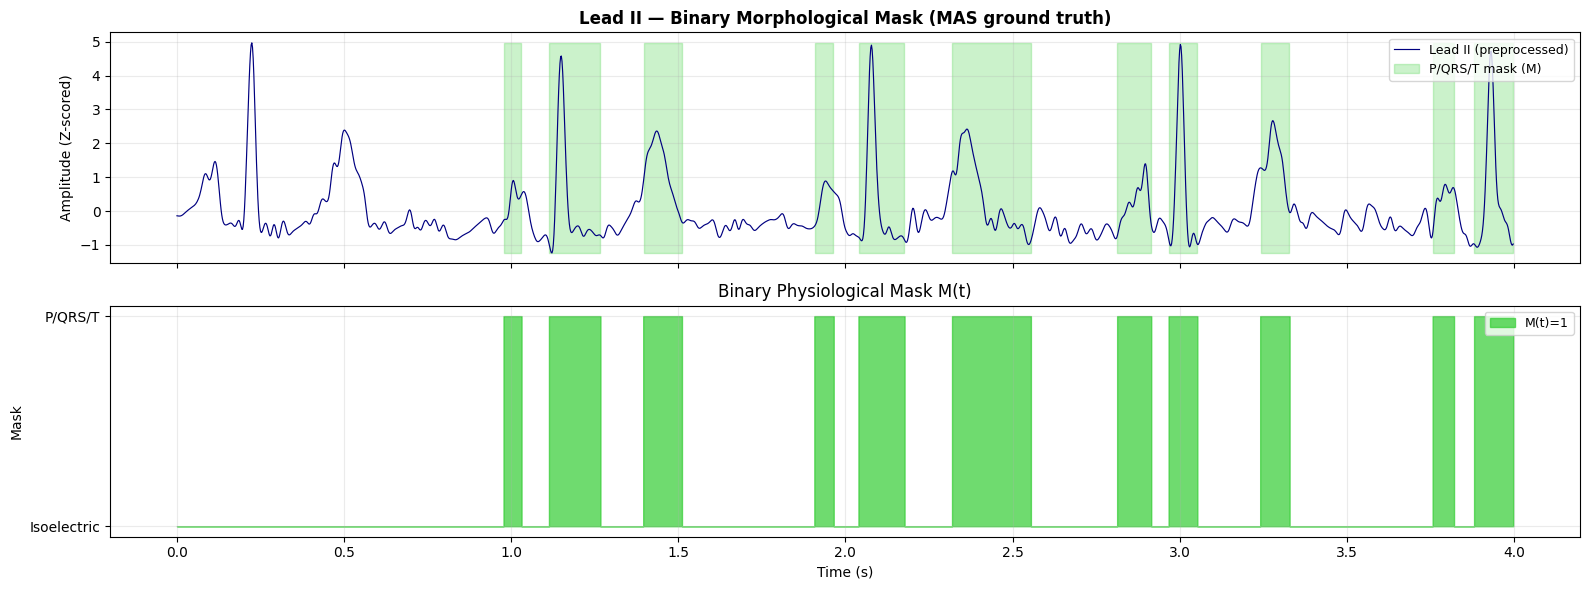

Masked samples : 1,648 / 5,000  (33.0%)


In [66]:
pe = 4 * FS # 4 seconds
t_plot = np.arange(pe) / FS

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

axes[0].plot(t_plot, demo_lead2[:pe], color='navy', lw=0.85,
             label='Lead II (preprocessed)', zorder=3)
axes[0].fill_between(t_plot, demo_lead2[:pe].min(), demo_lead2[:pe].max(),
                     where=mask[:pe],
                     color='limegreen', alpha=0.25, label='P/QRS/T mask (M)')
axes[0].set_ylabel('Amplitude (Z-scored)')
axes[0].set_title('Lead II — Binary Morphological Mask (MAS ground truth)', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.25)

mr = mask[:pe].astype(float)
axes[1].fill_between(t_plot, 0, mr, step='mid',
                     color='limegreen', alpha=0.7, label='M(t)=1')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Isoelectric', 'P/QRS/T'])
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Mask')
axes[1].set_title('Binary Physiological Mask M(t)')
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()
print(f"Masked samples : {mask.sum():,} / {SIGNAL_LEN:,}  ({coverage*100:.1f}%)")

## 10. Class Imbalance — `pos_weight` for BCEWithLogitsLoss

$$\text{pos\_weight}_c = \frac{N_{\text{neg},c}}{N_{\text{pos},c}}$$

Computed **only on the training fold** (folds 1–8) to avoid label leakage.

In [68]:
def compute_pos_weight(split_df, superclasses=SUPERCLASSES):
    """Per-class pos_weight tensor for BCEWithLogitsLoss."""
    n = len(split_df)
    weights = []
    print(f"{'Class':<6} {'N_pos':>7} {'N_neg':>7} {'pos_weight':>12}")
    print("-" * 36)
    for cls in superclasses:
        n_pos = int(split_df[cls].sum())
        n_neg = n - n_pos
        pw = n_neg / max(n_pos, 1)
        weights.append(pw)
        print(f"{cls:<6} {n_pos:>7,} {n_neg:>7,} {pw:>12.3f}")
    return torch.tensor(weights, dtype=torch.float32)

print("=== pos_weight (Training folds 1–8) ===")
pos_weight_tensor = compute_pos_weight(train_df)
print(f"\nTensor : {pos_weight_tensor}")

=== pos_weight (Training folds 1–8) ===
Class    N_pos   N_neg   pos_weight
------------------------------------
NORM     7,607   9,493        1.248
MI       4,389  12,711        2.896
STTC     4,094  13,006        3.177
CD       3,912  13,188        3.371
HYP      2,121  14,979        7.062

Tensor : tensor([1.2479, 2.8961, 3.1768, 3.3712, 7.0622])


## 11. PyTorch Dataset & DataLoaders (RAM-Cached)

To eliminate CPU bottlenecks during training, signals are pre-processed via `preprocess_record()` and cached into a single **NumPy array** in RAM prior to training.

`PTBXLDataset` now serves pre-computed tensors:
- **Input (`x`)**: `FloatTensor` shape `(3, 5000)` — Sourced from RAM-cached array (zero disk I/O).
- **Target (`y`)**: `FloatTensor` shape `(5,)` — Multi-label binary targets.

**Performance Optimization**: This transition reduces epoch time by ~95% by removing the repetitive overhead of digital filtering and disk reads from the training loop.

In [69]:
def load_and_preprocess_all(df, data_path):
    """Pre-loads all signals into a single NumPy array to avoid Disk I/O during training."""
    n_records = len(df)
    # Initialize array: (N, Leads, Length)
    all_x = np.zeros((n_records, 3, 5000), dtype=np.float32)
    
    print(f"Pre-processing {n_records} records...")
    for i in tqdm(range(n_records)):
        row = df.iloc[i]
        # This calls the Butterworth filter/scaling logic once
        all_x[i] = preprocess_record(row, data_path)
        
    return all_x

# Process each split once
print("--- Preparing Training Data ---")
x_train = load_and_preprocess_all(train_df, DATA_PATH)

print("--- Preparing Validation Data ---")
x_val = load_and_preprocess_all(val_df, DATA_PATH)

print("--- Preparing Test Data ---")
x_test = load_and_preprocess_all(test_df, DATA_PATH)


--- Preparing Training Data ---
Pre-processing 17100 records...


  0%|          | 0/17100 [00:00<?, ?it/s]

--- Preparing Validation Data ---
Pre-processing 2155 records...


  0%|          | 0/2155 [00:00<?, ?it/s]

--- Preparing Test Data ---
Pre-processing 2162 records...


  0%|          | 0/2162 [00:00<?, ?it/s]

In [70]:
class PTBXLDataset(Dataset):
    """PTB-XL dataset that reads from pre-loaded NumPy arrays."""

    def __init__(self, signals, dataframe, superclasses=SUPERCLASSES):
        self.signals = signals # This is the (N, 3, 5000) array from Step 1
        self.labels = dataframe[superclasses].values.astype(np.float32)

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        # Extremely fast: no disk read, no filtering, just a memory slice
        x = self.signals[idx]
        y = self.labels[idx]
        return torch.from_numpy(x), torch.from_numpy(y)

# === Instantiate splits with the new cached arrays ===
train_dataset = PTBXLDataset(x_train, train_df)
val_dataset   = PTBXLDataset(x_val, val_df)
test_dataset  = PTBXLDataset(x_test, test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches : {len(train_loader)}  ({len(train_dataset):,} records)")
print(f"Val batches : {len(val_loader)}  ({len(val_dataset):,} records)")
print(f"Test batches : {len(test_loader)}  ({len(test_dataset):,} records)")

# Quick shape check
xb, yb = next(iter(train_loader))
print(f"\nSample batch - x: {xb.shape}   y: {yb.shape}")

Train batches : 268  (17,100 records)
Val batches : 34  (2,155 records)
Test batches : 34  (2,162 records)

Sample batch - x: torch.Size([64, 3, 5000])   y: torch.Size([64, 5])


## 12. 1D-ResNet Architecture

### Architecture summary
```
Input (B, 3, 5000)
│
├─ Stem: Conv1d(3→32, k=15, s=2) → BN → ReLU           → (B, 32, 2500)
│
├─ Stage 1: 2× ResBlock(32→32,  s=1, k=15)             → (B, 32, 2500)
├─ Stage 2: 2× ResBlock(32→64,  s=2, k=15)             → (B, 64, 1250)
├─ Stage 3: 2× ResBlock(64→128, s=2, k=7)              → (B, 128, 625)
├─ Stage 4: 2× ResBlock(128→256,s=2, k=7)              → (B, 256, 313)
│
├─ Global Average Pool                                 → (B, 256)
└─ Linear(256→5)   [logits — BCE loss during training]   → (B, 5)
```
---

#### Tapered Receptive Field Logic

To maintain a balance between **clinical morphological grounding** and **parameter efficiency**, the model employs a variable kernel size strategy across its stages:

* **Stages 1–2 ($k=15$): High-Resolution Morphology**
    At these initial layers, the signal retains high temporal resolution. A kernel size of $k=15$ (approx. **30 ms** at 500 Hz) is utilized to accurately capture the steep slopes and peaks of **morphological landmarks**, specifically the P-wave and the QRS complex. This ensures the model "sees" enough of the wave to distinguish subtle structural abnormalities.

* **Stages 3–4 ($k=7$): Downsampled Rhythm Analysis**
    As the signal passes through the network, it is downsampled by $8\times$ and $16\times$ respectively. At Stage 4, the effective receptive field of a $k=7$ kernel expands to cover a massive temporal window of approximately **224 ms** ($7 \times 16 \times 2$ ms). This is more than sufficient for detecting **rhythm-based arrhythmias** (like AFib or Bradycardia) while significantly reducing the parameter count compared to using a wide kernel throughout.

---

**Kernel size = 15** in ResBlocks ≈ 30 ms @ 500 Hz — matches QRS width.
**Grad-CAM target** = `stage4[-1].conv2` (last conv before GAP, largest receptive field).

In [71]:
class ResBlock1D(nn.Module):
    """Basic 1D residual block with optional stride downsampling."""

    # kernel_size=15 to capture QRS time window.
    def __init__(self, in_ch, out_ch, stride=1, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, stride=1, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.dropout = nn.Dropout(0.2)

        self.skip = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.dropout(out)
        return F.relu(out + self.skip(x))


class ResNet1D(nn.Module):
    """18-layer-style 1D-ResNet for multi-label ECG classification.

    Input  : (B, 3, 5000)
    Output : (B, 5)  — raw logits (apply sigmoid for inference probabilities)
    """

    def __init__(self, n_leads=N_LEADS, n_classes=N_CLASSES):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(n_leads, 32, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True)
        )
        self.stage1 = self._make_stage(32,  32,  2, stride=1, kernel_size=15)
        self.stage2 = self._make_stage(32,  64, 2, stride=2, kernel_size=15)
        self.stage3 = self._make_stage(64, 128, 2, stride=2, kernel_size=7)
        self.stage4 = self._make_stage(128, 256, 2, stride=2, kernel_size=7)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(256, n_classes)

        # === He/Kaiming Initialization ===
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                # Kaiming Normal is standard for ReLU
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                # Standard practice: weights to 1, biases to 0
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                # Initialize the classifier head
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    @staticmethod
    def _make_stage(in_ch, out_ch, n_blocks, stride, kernel_size):
        layers = [ResBlock1D(in_ch, out_ch, stride, kernel_size)]
        for _ in range(1, n_blocks):
            layers.append(ResBlock1D(out_ch, out_ch, 1, kernel_size))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.gap(x).squeeze(-1)
        return self.head(x)

    def get_gradcam_target_layer(self):
        """Last conv layer before GAP — target for Grad-CAM."""
        return self.stage4[-1].conv2


# Instantiate
model = ResNet1D().to(DEVICE)

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model : ResNet1D (18-layer)")
print(f"Total params : {n_total:,}")
print(f"Trainable : {n_trainable:,}")

dummy = torch.zeros(2, N_LEADS, SIGNAL_LEN, device=DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"\nForward pass : {tuple(dummy.shape)} → {tuple(out.shape)}  ✓")
print(f"Grad-CAM target layer : {model.get_gradcam_target_layer()}")

Model : ResNet1D (18-layer)
Total params : 2,334,053
Trainable : 2,334,053

Forward pass : (2, 3, 5000) → (2, 5)  ✓
Grad-CAM target layer : Conv1d(256, 256, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)


## 13. Training Loop with Checkpointing

### Hyperparameters
| Parameter | Value |
|-----------|-------|
| Optimiser | AdamW |
| Learning rate | 1e-3 |
| Weight decay | 1e-4 |
| Batch size | 64 |
| Scheduler | ReduceLROnPlateau (patience=5, factor=0.1, monitor=val_AUC) |
| Loss | BCEWithLogitsLoss with per-class `pos_weight` |

### Model Saving Strategy
Three checkpoints are maintained:
- **`best_model.pt`** — saved whenever validation Macro-AUC improves (used for test evaluation)
- **`latest_checkpoint.pt`** — saved every epoch (allows training resumption)
- **`final_model.pt`** — saved after all epochs complete

In [72]:
# === Loss & optimiser ===
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor.to(DEVICE)
)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=FACTOR_LR,
    patience=PATIENCE_LR
)


# === Checkpoint helpers ===
def save_checkpoint(state, filepath):
    """Save a training checkpoint dict to disk."""
    torch.save(state, filepath)

def load_checkpoint(filepath, model, optimizer=None, scheduler=None):
    """Restore model (and optionally optimiser/scheduler) from a checkpoint."""
    ckpt = torch.load(filepath, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    if optimizer  is not None and 'optimizer_state_dict'  in ckpt:
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    if scheduler  is not None and 'scheduler_state_dict'  in ckpt:
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    print(f"Loaded checkpoint from '{filepath}'")
    print(f"  Epoch {ckpt.get('epoch', '?')}  |  Best val AUC: {ckpt.get('best_val_auc', 'N/A'):.4f}")
    return ckpt


# === One-epoch helpers ===
def run_epoch(loader, model, criterion, optimizer, train=True,
              batch_bar=False, epoch=None, total_epochs=None):
    """Run one full pass through a DataLoader.

    Returns
    -------
    avg_loss : float
    macro_auc : float  (−1 if labels missing)
    """
    if train and optimizer is None:
        raise ValueError("optimizer must be provided when train=True")

    model.train(train)
    total_loss = 0.0
    all_preds, all_labels = [], []
    dataset_size = len(loader.dataset) if hasattr(loader, 'dataset') else 0

    iterator = loader
    if batch_bar:
        try:
            import importlib
            _tqdm = importlib.import_module("tqdm.auto").tqdm
            mode = "Train" if train else "Val"
            if epoch is not None and total_epochs is not None:
                desc = f"Epoch {epoch}/{total_epochs} {mode}"
            else:
                desc = f"{mode} batches"
            iterator = _tqdm(loader, desc=desc, unit="batch",
                             leave=False, position=1, dynamic_ncols=True)
        except Exception:
            iterator = loader

    with torch.set_grad_enabled(train):
        for xb, yb in iterator:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(xb)
            loss    = criterion(logits, yb)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            
            # --- Memory Efficient Detach ---
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                all_preds.append(probs.cpu().numpy())
            all_labels.append(yb.detach().cpu().numpy())

            if batch_bar and hasattr(iterator, 'set_postfix'):
                iterator.set_postfix({'loss': f"{loss.item():.4f}"})

    if batch_bar and hasattr(iterator, 'close'):
        iterator.close()

    if dataset_size == 0 or len(all_preds) == 0:
        return 0.0, -1.0

    avg_loss = total_loss / dataset_size
    all_preds  = np.concatenate(all_preds,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    try:
        # --- Robust AUC calculation for Multi-label ---
        macro_auc = roc_auc_score(all_labels, all_preds, average='macro', multi_class='ovr')
    except ValueError:
        macro_auc = -1.0

    return avg_loss, macro_auc


print("Loss, optimiser, scheduler, and checkpoint helpers defined ✓")
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")

Loss, optimiser, scheduler, and checkpoint helpers defined ✓
Checkpoints will be saved to: /kaggle/working/checkpoint


In [73]:
# =============================================================================
# TRAINING LOOP
# =============================================================================
BEST_CKPT   = os.path.join(CHECKPOINT_DIR, "best_model.pt")
LATEST_CKPT = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pt")

patience_counter = 0
EARLY_STOP_PATIENCE = 12  # roughly 2x-3x scheduler patience
best_val_auc   = 0.0
train_history  = {'loss': [], 'auc': []}
val_history    = {'loss': [], 'auc': []}

try:
    from tqdm.auto import tqdm
except ImportError:
    # Fallback keeps the loop runnable if tqdm is unavailable.
    def tqdm(iterable, **kwargs):
        _ = kwargs
        return iterable

epoch_bar = tqdm(range(1, N_EPOCHS + 1), desc="Training", unit="epoch")

for epoch in epoch_bar:
    t0 = time.time()

    tr_loss, tr_auc = run_epoch(
        train_loader, model, criterion, optimizer, train=True,
        batch_bar=True, epoch=epoch, total_epochs=N_EPOCHS
    )
    vl_loss, vl_auc = run_epoch(
        val_loader, model, criterion, optimizer, train=False,
        batch_bar=True, epoch=epoch, total_epochs=N_EPOCHS
    )

    scheduler.step(vl_auc)
    current_lr = optimizer.param_groups[0]['lr']

    train_history['loss'].append(tr_loss)
    train_history['auc'].append(tr_auc)
    val_history['loss'].append(vl_loss)
    val_history['auc'].append(vl_auc)

    elapsed = time.time() - t0
    if hasattr(epoch_bar, "set_postfix"):
        epoch_bar.set_postfix({
            'tr_loss': f"{tr_loss:.4f}",
            'tr_auc': f"{tr_auc:.4f}",
            'vl_loss': f"{vl_loss:.4f}",
            'vl_auc': f"{vl_auc:.4f}",
            'lr': f"{current_lr:.2e}",
            'sec': f"{elapsed:.1f}"
        })

    # Save latest checkpoint every epoch
    save_checkpoint({
        'epoch'               : epoch,
        'model_state_dict'    : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss'          : tr_loss,
        'val_loss'            : vl_loss,
        'val_auc'             : vl_auc,
        'best_val_auc'        : best_val_auc,
    }, LATEST_CKPT)

    # Save best model when val AUC improves
    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        patience_counter = 0  # Reset counter: better model found
        save_checkpoint({
            'epoch'            : epoch,
            'model_state_dict' : model.state_dict(),
            'val_auc'          : vl_auc,
            'best_val_auc'     : best_val_auc,
            'superclasses'     : SUPERCLASSES,
            'n_leads'          : N_LEADS,
            'signal_len'       : SIGNAL_LEN,
        }, BEST_CKPT)
        msg = f"*** New best val AUC: {best_val_auc:.4f} - checkpoint saved to {BEST_CKPT}"
        if hasattr(epoch_bar, "write"):
            epoch_bar.write(msg)
        else:
            print(msg)
    else:
        patience_counter += 1  # No improvement
        msg = f"No improvement for {patience_counter} epoch(s)."
        if hasattr(epoch_bar, "write"):
            epoch_bar.write(msg)

    # Exit condition
    if patience_counter >= EARLY_STOP_PATIENCE:
        _stop_msg = f"Early stopping triggered at epoch {epoch}. Terminating."
        if hasattr(epoch_bar, "write"):
            epoch_bar.write(_stop_msg)
        break

if hasattr(epoch_bar, "close"):
    epoch_bar.close()

# Save final model
FINAL_CKPT = os.path.join(CHECKPOINT_DIR, "final_model.pt")
save_checkpoint({
    'epoch'            : N_EPOCHS,
    'model_state_dict' : model.state_dict(),
    'best_val_auc'     : best_val_auc,
    'train_history'    : train_history,
    'val_history'      : val_history,
}, FINAL_CKPT)

print(f"\nTraining complete.")
print(f"  Best val Macro-AUC : {best_val_auc:.4f}")
print(f"  Best model saved   : {BEST_CKPT}")
print(f"  Final model saved  : {FINAL_CKPT}")

Training:   0%|          | 0/70 [00:00<?, ?epoch/s]

Epoch 1/70 Train:   0%|          | 0/268 [00:00<?, ?batch/s]

Epoch 1/70 Val:   0%|          | 0/34 [00:00<?, ?batch/s]

*** New best val AUC: 0.8833 - checkpoint saved to /kaggle/working/checkpoint/best_model.pt


Epoch 2/70 Train:   0%|          | 0/268 [00:00<?, ?batch/s]

...

Epoch 32/70 Val:   0%|          | 0/34 [00:00<?, ?batch/s]

No improvement for 11 epoch(s).


Epoch 33/70 Train:   0%|          | 0/268 [00:00<?, ?batch/s]

Epoch 33/70 Val:   0%|          | 0/34 [00:00<?, ?batch/s]

No improvement for 12 epoch(s).
Early stopping triggered at epoch 33. Terminating.

Training complete.
  Best val Macro-AUC : 0.9034
  Best model saved   : /kaggle/working/checkpoint/best_model.pt
  Final model saved  : /kaggle/working/checkpoint/final_model.pt


### Training Curves

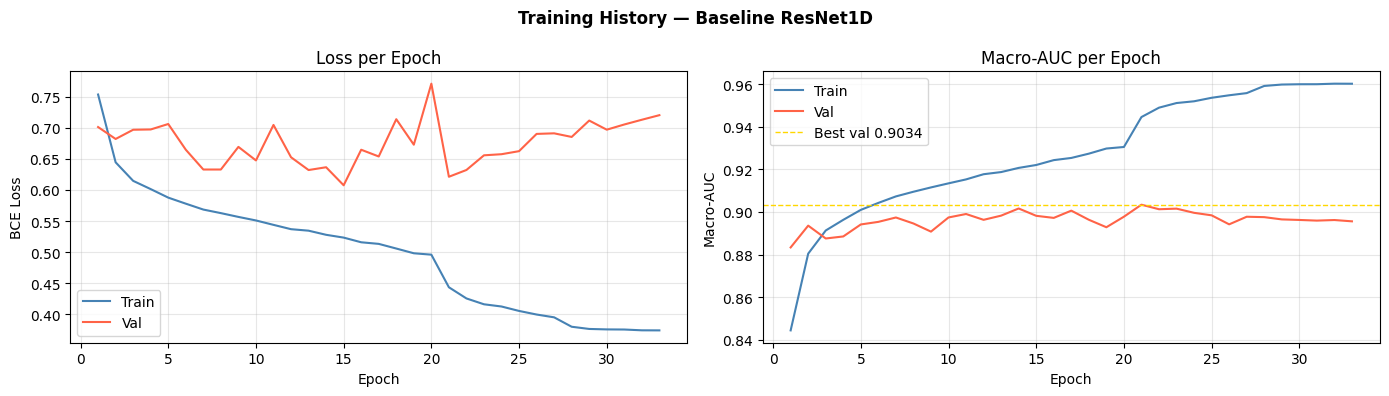

In [74]:
epochs_x = list(range(1, len(train_history['loss']) + 1))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_x, train_history['loss'], label='Train', color='steelblue')
axes[0].plot(epochs_x, val_history['loss'],   label='Val',   color='tomato')
axes[0].set(title='Loss per Epoch', xlabel='Epoch', ylabel='BCE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_x, train_history['auc'], label='Train', color='steelblue')
axes[1].plot(epochs_x, val_history['auc'],   label='Val',   color='tomato')
axes[1].axhline(best_val_auc, color='gold', ls='--', lw=1, label=f'Best val {best_val_auc:.4f}')
axes[1].set(title='Macro-AUC per Epoch', xlabel='Epoch', ylabel='Macro-AUC')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — Baseline ResNet1D', fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Test-Set Evaluation

We reload the **best checkpoint** (highest validation Macro-AUC) before
running the held-out test set to avoid any optimistic bias from the last epoch.

Loaded checkpoint from '/kaggle/working/checkpoint/best_model.pt'
  Epoch 21  |  Best val AUC: 0.9034
=== Test Set Evaluation ===
Class       AUC
------------------
NORM     0.9303
MI       0.9069
STTC     0.9185
CD       0.9234
HYP      0.8196
------------------
MACRO    0.8997


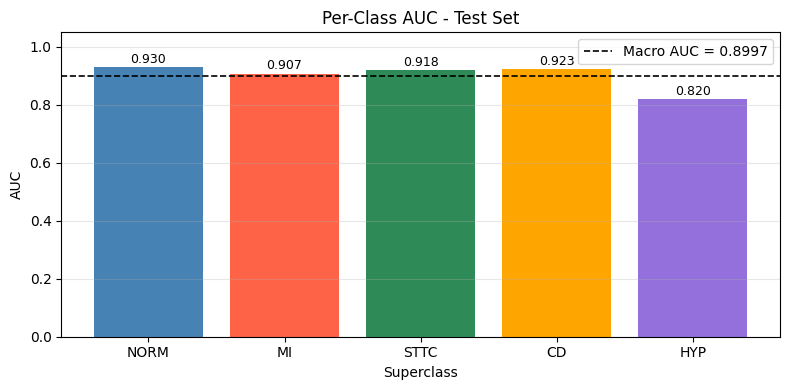

In [75]:
# Load best model for test evaluation
best_ckpt_path = os.path.join(CHECKPOINT_DIR, "best_model.pt")
best_model = ResNet1D().to(DEVICE)
_ = load_checkpoint(best_ckpt_path, best_model)

# Collect test predictions
best_model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        probs = torch.sigmoid(best_model(xb)).cpu().numpy()
        test_preds.append(probs)
        test_labels.append(yb.numpy())

test_preds  = np.concatenate(test_preds,  axis=0)
test_labels = np.concatenate(test_labels, axis=0)

# Per-class AUC
print("=== Test Set Evaluation ===")
print(f"{'Class':<6} {'AUC':>8}")
print("-" * 18)
aucs = []
for i, cls in enumerate(SUPERCLASSES):
    try:
        auc = roc_auc_score(test_labels[:, i], test_preds[:, i])
    except ValueError:
        auc = float('nan')
    aucs.append(auc)
    print(f"{cls:<6} {auc:>8.4f}")

macro_auc = np.nanmean(aucs)
print("-" * 18)
print(f"{'MACRO':<6} {macro_auc:>8.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'mediumpurple']
bars   = ax.bar(SUPERCLASSES, aucs, color=colors)
ax.axhline(macro_auc, color='black', ls='--', lw=1.2, label=f'Macro AUC = {macro_auc:.4f}')
for bar, a in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{a:.3f}', ha='center', va='bottom', fontsize=9)
ax.set(ylim=[0, 1.05], title='Per-Class AUC - Test Set',
       xlabel='Superclass', ylabel='AUC')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 15. Grad-CAM Implementation

### Algorithm
1. Forward pass → logit $y^c$ for class $c$
2. Backpropagate to the **last conv layer** (before GAP)
3. Importance weights: $\alpha^c_k = \frac{1}{T}\sum_t \frac{\partial y^c}{\partial A^k_t}$
4. Heatmap: $L^c = \text{ReLU}(\sum_k \alpha^c_k A^k)$
5. Upsample from ≈313 → 5000 samples via linear interpolation
6. Normalise to [0, 1]

In [76]:
class GradCAM1D:
    """Gradient-weighted Class Activation Mapping for 1D-ResNet."""

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.layer_activations = None
        self.layer_gradients = None
        self.fwd_hook = target_layer.register_forward_hook(self.save_activations)
        self.bwd_hook = target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, module, inp, out):
        self.layer_activations = out.detach()

    def save_gradients(self, module, grad_in, grad_out):
        self.layer_gradients = grad_out[0].detach()

    def remove_hooks(self):
        """Call when finished to free hooks."""
        self.fwd_hook.remove()
        self.bwd_hook.remove()

    def compute(self, input_tensor, class_idx, output_length=SIGNAL_LEN):
        """
        Parameters
        ----------
        input_tensor : Tensor (1, 3, 5000) - on same device as model
        class_idx    : int  0=NORM 1=MI 2=STTC 3=CD 4=HYP

        Returns
        -------
        np.ndarray (output_length,) in [0, 1]
        """
        self.model.eval()
        inp = input_tensor.clone().requires_grad_(True)
        logits = self.model(inp) # (1, 5)
        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.layer_gradients.mean(dim=-1).squeeze() # (C,) 
        act = self.layer_activations.squeeze() # (C, T)
        cam = F.relu((weights[:, None] * act).sum(dim=0)) # (T,)

        cam_np = cam.cpu().numpy()
        cam_up = np.interp(
            np.linspace(0, len(cam_np) - 1, output_length),
            np.arange(len(cam_np)), cam_np
        )
        if cam_up.max() > 1e-10:
            cam_up /= cam_up.max()
        return cam_up


gcam = GradCAM1D(best_model, best_model.get_gradcam_target_layer())
print(f"GradCAM1D attached to: {best_model.get_gradcam_target_layer()}")
print("Class index map:", {c: i for i, c in enumerate(SUPERCLASSES)})

GradCAM1D attached to: Conv1d(256, 256, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
Class index map: {'NORM': 0, 'MI': 1, 'STTC': 2, 'CD': 3, 'HYP': 4}


## 16. Grad-CAM Heatmap Visualisation & MAS Per Class

For each of the 5 superclasses we:
1. Select a correctly predicted test sample
2. Compute the Grad-CAM heatmap
3. Overlay it on the Lead II signal alongside the morphological mask
4. Report the MAS score

In [77]:
# === Build a small index of correctly predicted test samples ===
THRESHOLD = 0.5
binary_preds = (test_preds >= THRESHOLD).astype(int)

# Map each superclass to a suitable test ECG index
class_sample_idx = {}
for i, cls in enumerate(SUPERCLASSES):
    # find samples where the true label is 1 and prediction is correct
    correct = np.where((test_labels[:, i] == 1) & (binary_preds[:, i] == 1))[0]
    if len(correct) == 0:
        # fallback: any true positive regardless of prediction
        correct = np.where(test_labels[:, i] == 1)[0]
    if len(correct) > 0:
        class_sample_idx[cls] = int(correct[0])
    else:
        class_sample_idx[cls] = 0   # absolute fallback

print("Selected test sample indices per class:")
for cls, idx in class_sample_idx.items():
    print(f"  {cls:<6}: test_df row {idx}")

Selected test sample indices per class:
  NORM  : test_df row 0
  MI    : test_df row 5
  STTC  : test_df row 19
  CD    : test_df row 6
  HYP   : test_df row 24


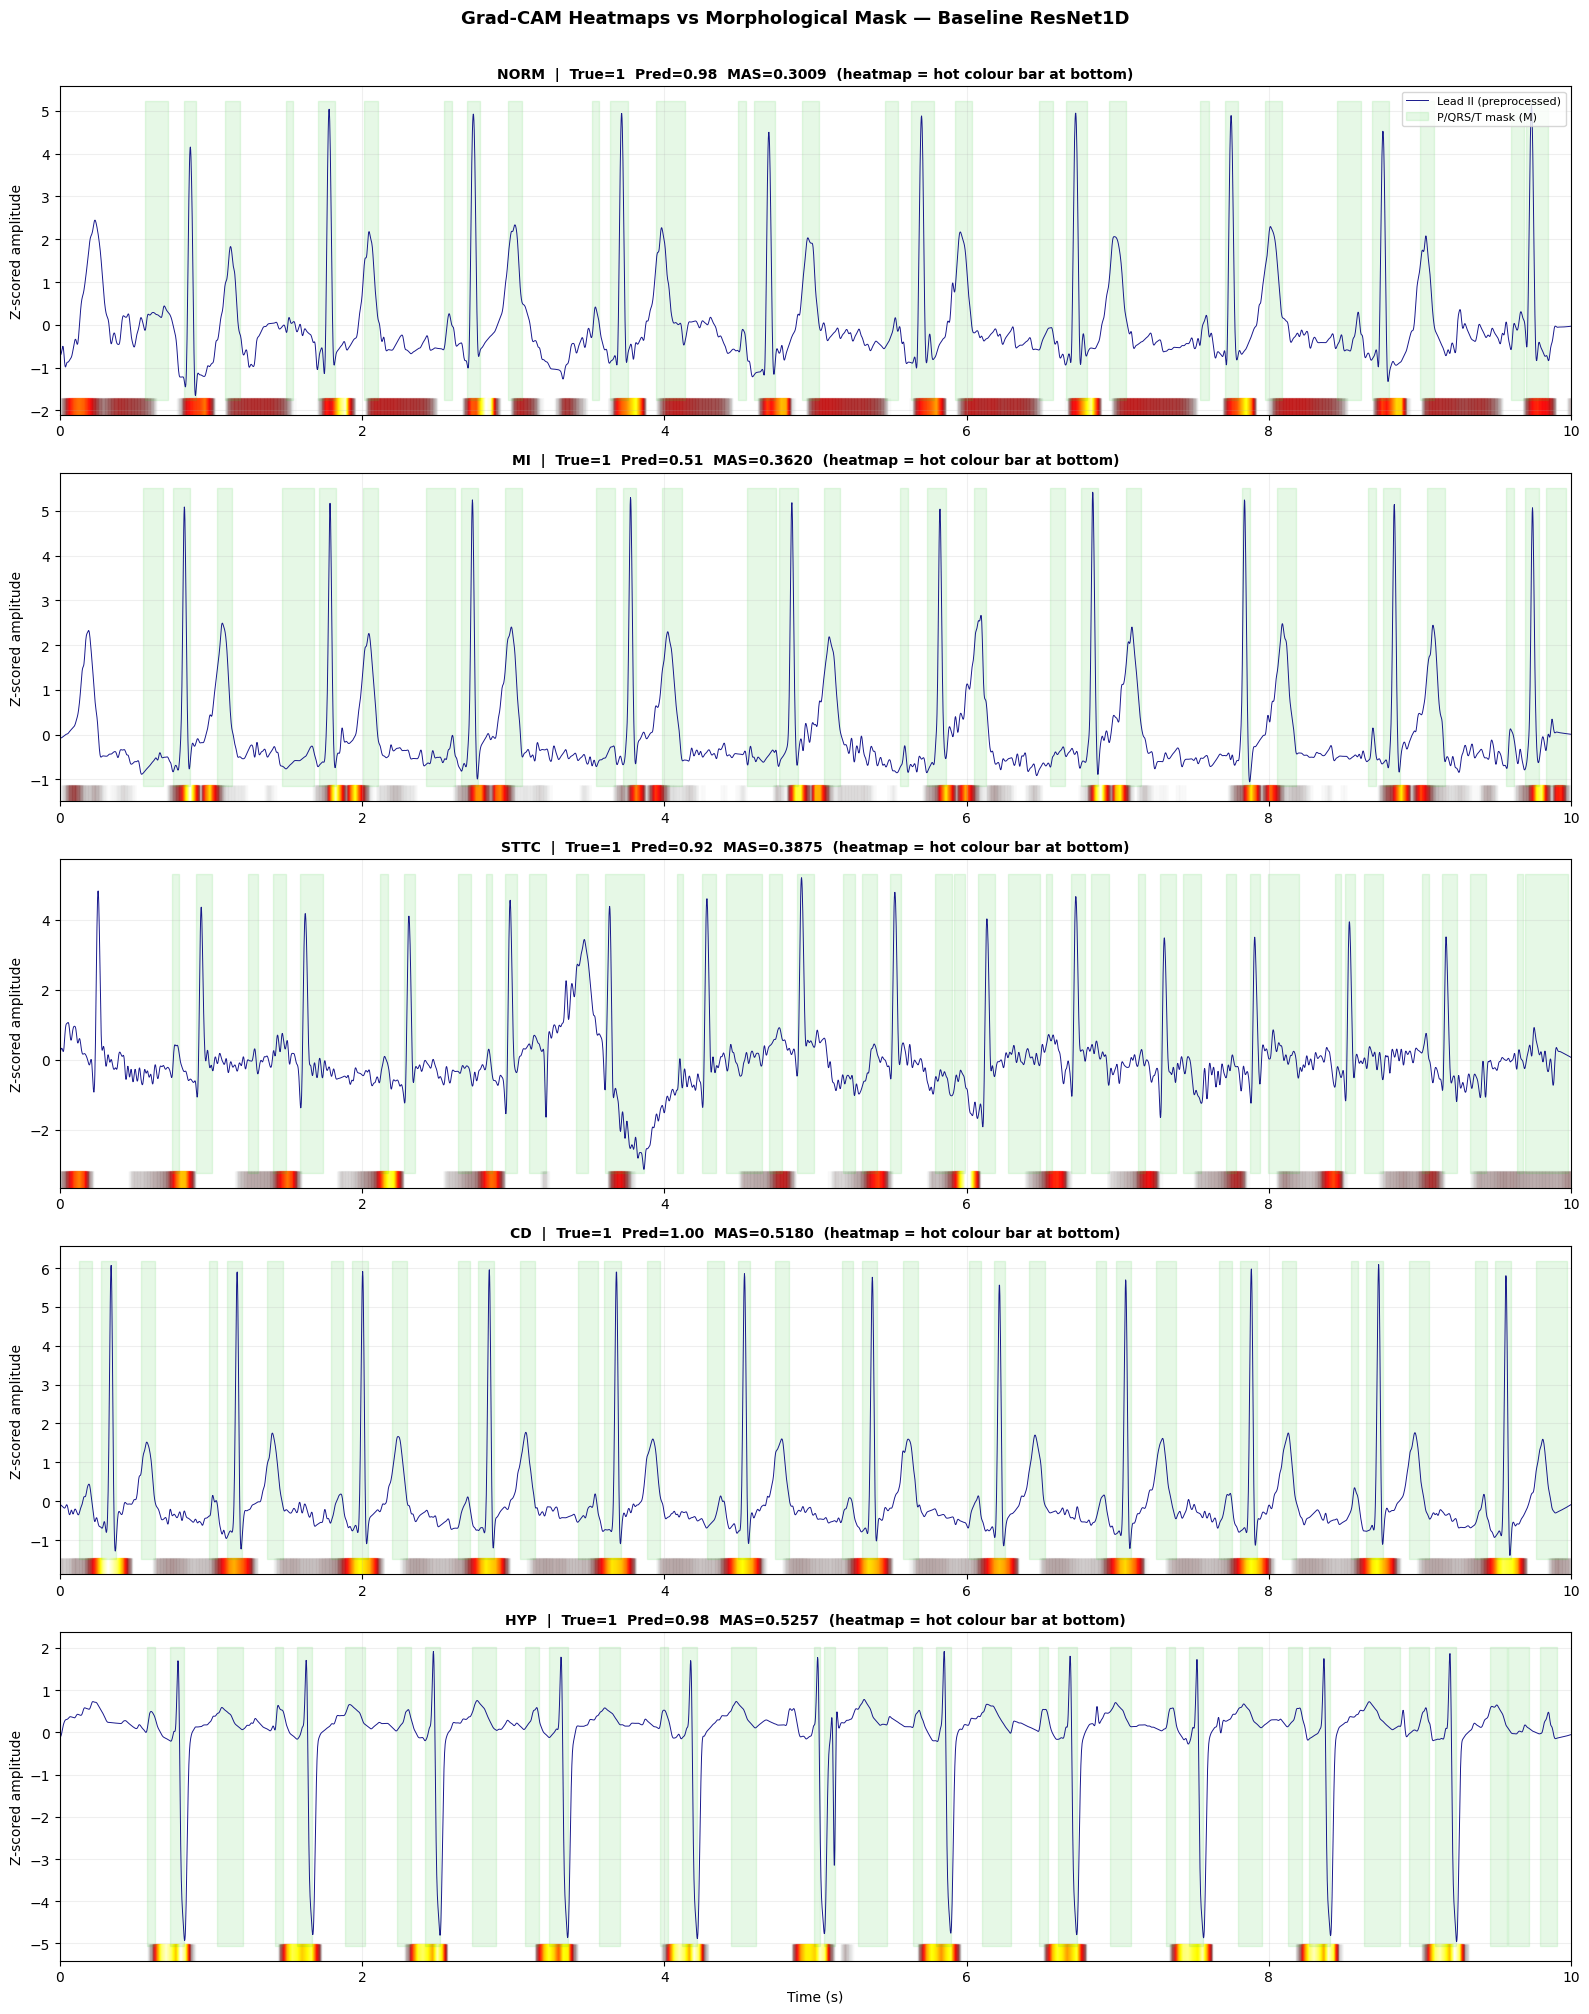


=== Medical Alignment Score Summary ===
Class       MAS
----------------
NORM     0.3009
MI       0.3620
STTC     0.3875
CD       0.5180
HYP      0.5257
MEAN     0.4188

Grad-CAM hooks removed.


In [78]:
# === Grad-CAM + MAS for each class ===
fig, axes = plt.subplots(len(SUPERCLASSES), 1, figsize=(16, 4 * len(SUPERCLASSES)))
mas_scores = {}

test_df_reset = test_df.reset_index(drop=True)

for row_i, cls in enumerate(SUPERCLASSES):
    class_idx = SUPERCLASSES.index(cls)
    sample_i  = class_sample_idx[cls]
    ecg_row   = test_df_reset.iloc[sample_i]

    # Preprocess & load to device
    x_np  = preprocess_record(ecg_row) # (3, 5000)
    x_t   = torch.from_numpy(x_np).unsqueeze(0).to(DEVICE) # (1, 3, 5000)

    # Grad-CAM heatmap
    heatmap = gcam.compute(x_t, class_idx) # (5000,)

    # Morphological mask (Lead II)
    mask    = build_morphological_mask(x_np[1])
    mas     = compute_mas(heatmap, mask)
    mas_scores[cls] = mas

    # === Plot ===
    ax   = axes[row_i]
    t    = np.arange(SIGNAL_LEN) / FS
    l2   = x_np[1]

    # Signal
    ax.plot(t, l2, color='navy', lw=0.7, alpha=0.9, label='Lead II (preprocessed)')

    # Heatmap as coloured fill under signal
    norm_hm = heatmap / (heatmap.max() + 1e-10)
    cmap    = cm.get_cmap('hot')
    for j in range(SIGNAL_LEN - 1):
        c = cmap(norm_hm[j])
        ax.axvspan(t[j], t[j+1], ymin=0.0, ymax=0.05,
                   color=c, alpha=float(norm_hm[j]))

    # Morphological mask boundary
    ax.fill_between(t, l2.min() - 0.1, l2.max() + 0.1,
                    where=mask, color='limegreen', alpha=0.12,
                    label='P/QRS/T mask (M)')

    true_lbl = int(test_labels[sample_i, class_idx])
    pred_prob = float(test_preds[sample_i, class_idx])
    ax.set_title(
        f"{cls}  |  True={true_lbl}  Pred={pred_prob:.2f}  "
        f"MAS={mas:.4f}  (heatmap = hot colour bar at bottom)",
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Z-scored amplitude')
    ax.set_xlim([0, 10])
    ax.grid(True, alpha=0.2)
    if row_i == 0:
        ax.legend(loc='upper right', fontsize=8)
    if row_i == len(SUPERCLASSES) - 1:
        ax.set_xlabel('Time (s)')

plt.suptitle('Grad-CAM Heatmaps vs Morphological Mask — Baseline ResNet1D',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

# === MAS summary table ===
print("\n=== Medical Alignment Score Summary ===")
print(f"{'Class':<6} {'MAS':>8}")
print("-" * 16)
for cls, mas in mas_scores.items():
    print(f"{cls:<6} {mas:>8.4f}")
print(f"{'MEAN':<6} {np.mean(list(mas_scores.values())):>8.4f}")

gcam.remove_hooks()
print("\nGrad-CAM hooks removed.")


# # === Sensitivity-Weighted Grad-CAM + MAS for ALL leads ===
# fig, axes = plt.subplots(len(SUPERCLASSES) * 3, 1, figsize=(16, 3 * len(SUPERCLASSES) * 3))
# mas_scores_detailed = {cls: [] for cls in SUPERCLASSES}
# lead_names = ['Lead I', 'Lead II', 'Lead V']

# test_df_reset = test_df.reset_index(drop=True)

# for row_i, cls in enumerate(SUPERCLASSES):
#     class_idx = SUPERCLASSES.index(cls)
#     sample_i  = class_sample_idx[cls]
#     ecg_row   = test_df_reset.iloc[sample_i]

#     # Preprocess & load (3, 5000)
#     x_np  = preprocess_record(ecg_row) 
#     x_t   = torch.from_numpy(x_np).unsqueeze(0).to(DEVICE).requires_grad_(True)
    
#     # 1. Compute Global Heatmap (Temporal focus across all leads)
#     heatmap_global = gcam.compute(x_t, class_idx) 
    
#     # 2. Compute Lead Importance (Sensitivity/Saliency)
#     # We find which lead's raw pixels actually drive the class score
#     self_model = gcam.model
#     self_model.zero_grad()
#     logits = self_model(x_t)
#     logits[0, class_idx].backward()
    
#     # Extract gradient magnitude per lead (norm across time)
#     lead_grads = x_t.grad.abs().squeeze().cpu().numpy() # (3, 5000)
#     lead_importance = lead_grads.mean(axis=1) # (3,)
#     # Normalize weights so the most important lead has weight 1.0
#     lead_weights = lead_importance / (lead_importance.max() + 1e-10)

#     # 3. Plot and calculate weighted MAS
#     for lead_j in range(3):
#         ax_idx = row_i * 3 + lead_j
#         ax     = axes[ax_idx]
#         sig    = x_np[lead_j]
        
#         # Apply lead-specific weight to the global heatmap
#         # This makes the "hot" bar dimmer for irrelevant leads
#         heatmap_lead = heatmap_global * lead_weights[lead_j]
#         norm_hm = heatmap_lead / (heatmap_global.max() + 1e-10)
        
#         # Calculate MAS
#         mask = build_morphological_mask(sig)
#         mas  = compute_mas(heatmap_lead, mask) 
#         mas_scores_detailed[cls].append(mas)

#         # Visuals
#         t = np.arange(SIGNAL_LEN) / FS
#         ax.plot(t, sig, color='navy', lw=0.7, alpha=0.8, label=f'{lead_names[lead_j]}')
        
#         cmap = plt.get_cmap('hot')
#         step = 5 
#         for j in range(0, SIGNAL_LEN - step, step):
#             h_val = norm_hm[j]
#             if h_val > 0.01: # Optimization: only plot if there's focus
#                 c = cmap(h_val)
#                 ax.axvspan(t[j], t[j+step], ymin=0, ymax=0.05, color=c, alpha=float(h_val))

#         ax.fill_between(t, sig.min()-0.1, sig.max()+0.1, where=mask, 
#                         color='limegreen', alpha=0.1)

#         # Meta
#         if lead_j == 0:
#             true_lbl = int(test_labels[sample_i, class_idx])
#             pred_prob = float(test_preds[sample_i, class_idx])
#             ax.set_title(f"CLASS: {cls} | True={true_lbl} Prob={pred_prob:.2f} | Lead Weights: I={lead_weights[0]:.2f}, II={lead_weights[1]:.2f}, V={lead_weights[2]:.2f}", 
#                          loc='left', fontsize=11, fontweight='bold')
        
#         ax.set_ylabel(f'{lead_names[lead_j]}\nMAS: {mas:.3f}')
#         ax.set_xlim([0, 10])

# plt.suptitle('Sensitivity-Weighted Grad-CAM Analysis — LUMS Baseline ResNet', fontsize=16, fontweight='bold', y=1.002)
# plt.tight_layout()
# plt.show()

# # === Detailed MAS Summary Table ===
# print("\n=== Medical Alignment Score (Lead Breakdown) ===")
# print(f"{'Class':<6} | {'Lead I':>8} | {'Lead II':>8} | {'Lead V':>8} | {'MAX MAS':>10}")
# print("-" * 55)

# for cls, scores in mas_scores_detailed.items():
#     l1, l2, lv = scores
#     max_mas = np.max(scores)
#     print(f"{cls:<6} | {l1:>8.4f} | {l2:>8.4f} | {lv:>8.4f} | {max_mas:>10.4f}")
    
# gcam.remove_hooks()
# print("\nGrad-CAM hooks removed.")

## 17. Pipeline Summary

| Spec Section | Implementation |
|---|---|
|Lead Config | Leads I, II, V1 → `(3×5000)` tensor |
|Butterworth 0.5–40 Hz | `design_butterworth` + `filtfilt` |
|Z-score normalisation | Per-lead in `preprocess_record` |
|Dataset split | Folds 1–8 / 9 / 10; zero patient overlap |
|ResNet1D | 4 stages × 2 ResBlocks, GAP, sigmoid head |
|BCEWithLogitsLoss + pos_weight | `compute_pos_weight(train_df)` |
|AdamW + ReduceLROnPlateau | lr=1e-3, wd=1e-4, patience=5 |
|Model saving | best / latest / final checkpoints |
|Grad-CAM | Hook-based `GradCAM1D`, target=`stage4[-1].conv2` |
|MAS Metric | `build_morphological_mask` + `compute_mas` |

In [79]:
import glob

print("=== BASELINE PIPELINE COMPLETE ===")
print(f"Best Val Macro-AUC  : {best_val_auc:.4f}")
print(f"Test Macro-AUC      : {macro_auc:.4f}")
print(f"Mean MAS (test)     : {np.mean(list(mas_scores.values())):.4f}")
print()
print("Checkpoints saved:")

search_pattern = os.path.join(CHECKPOINT_DIR, "*.pt")
ckpt_files = sorted(glob.glob(search_pattern))

for ckpt_path in ckpt_files:
    # Get the file size in bytes and convert to MB
    size_mb = os.path.getsize(ckpt_path) / 1e6
    # Get just the filename (e.g., 'best_model.pt') from the full path
    file_name = os.path.basename(ckpt_path)
    
    print(f"  {file_name:<30} {size_mb:.1f} MB")

=== BASELINE PIPELINE COMPLETE ===
Best Val Macro-AUC  : 0.9034
Test Macro-AUC      : 0.8997
Mean MAS (test)     : 0.4188

Checkpoints saved:
  best_model.pt                  9.4 MB
  final_model.pt                 9.4 MB
  latest_checkpoint.pt           28.1 MB
